In [ ]:
import matplotlib.pyplot as plt
import numpy as np

import cdmprof

%load_ext autoreload
%autoreload 2
%matplotlib inline

## Initialize parser

In [ ]:
parser = cdmprof.SympyParser()

## Test expression parsing

In [3]:
expr = '(a0 * (1 + x)**a1)**-1'
print(f"Expression: {expr}")
print(f"Number of free parameters: {parser.count_free(expr)}")
print(f"\nParsed SymPy expression:")
parser.parse(expr)

Expression: (a0 * (1 + x)**a1)**-1
Number of free parameters: 2

Parsed SymPy expression:


1/(a0*(x + 1)**a1)

## Generate C code

In [4]:
print(parser.to_c(expr))

double rho(double r, double Rs, double a0, double a1) {
    return pow(1 + r/Rs, -a1)/a0;
}


In [5]:
print(parser.to_c_file(expr))

#include <math.h>

double rho(double r, double Rs, double a0, double a1) {
    return pow(1 + r/Rs, -a1)/a0;
}


## Compile C on the fly and compare with NumPy

In [6]:
# Compile to C function
f_c = parser.to_cfunc(expr)

# Get NumPy version
f_np = parser.to_numpy(expr)

In [7]:
# Test parameters
r = np.linspace(0.1, 10, 100)
Rs = 1.0
a0 = 1.0
a1 = 2.0

# Evaluate both
result_c = f_c(r, Rs, a0, a1)
result_np = f_np(r, Rs, a0, a1)

print(f"Results match: {np.allclose(result_c, result_np)}")

Results match: True


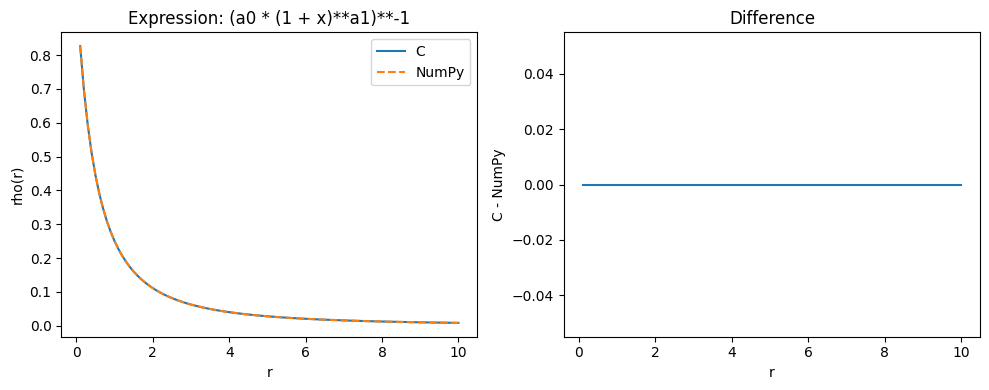

In [8]:
# Plot comparison
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(r, result_c, label='C')
plt.plot(r, result_np, '--', label='NumPy')
plt.xlabel('r')
plt.ylabel('rho(r)')
plt.legend()
plt.title(f'Expression: {expr}')

plt.subplot(1, 2, 2)
plt.plot(r, result_c - result_np)
plt.xlabel('r')
plt.ylabel('C - NumPy')
plt.title('Difference')

plt.tight_layout()
plt.show()

## Benchmark: C vs NumPy

In [12]:
r_large = np.linspace(0.1, 10, 100000)

print("NumPy:")
%timeit f_np(r_large, Rs, a0, a1)

print("\nC (cffi):")
%timeit f_c(r_large, Rs, a0, a1)

NumPy:
533 μs ± 2.29 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)

C (cffi):
552 μs ± 2.63 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


## Test multiple expressions

In [10]:
expressions = [
    '(a0 * (1 + x)**a1)**-1',
    'a0 * exp(-x / a1)',
    'a0 * x**a1',
    'a0 / (1 + x**2)',
]

for expr in expressions:
    print(f"Expression: {expr}")
    print(parser.to_c(expr))
    print()

Expression: (a0 * (1 + x)**a1)**-1
double rho(double r, double Rs, double a0, double a1) {
    return pow(1 + r/Rs, -a1)/a0;
}

Expression: a0 * exp(-x / a1)
double rho(double r, double Rs, double a0, double a1) {
    return a0*exp(-r/(Rs*a1));
}

Expression: a0 * x**a1
double rho(double r, double Rs, double a0, double a1) {
    return a0*pow(r/Rs, a1);
}

Expression: a0 / (1 + x**2)
double rho(double r, double Rs, double a0) {
    return a0/(1 + pow(r, 2)/pow(Rs, 2));
}



## Generate C array of functions

In [11]:
print(parser.to_c_array(expressions))

#include <math.h>

double rho_0(double r, double Rs, double a0, double a1) {
    return pow(1 + r/Rs, -a1)/a0;
}

double rho_1(double r, double Rs, double a0, double a1) {
    return a0*exp(-r/(Rs*a1));
}

double rho_2(double r, double Rs, double a0, double a1) {
    return a0*pow(r/Rs, a1);
}

double rho_3(double r, double Rs, double a0) {
    return a0/(1 + pow(r, 2)/pow(Rs, 2));
}

typedef double (*rho_func)(double, double, double, double);

const rho_func rho_functions[] = {
    rho_0, rho_1, rho_2, rho_3
};

const int n_rho_functions = 4;
